# ENSIA Student Performance Classification Analysis

## 📋 Project Overview

This analysis develops predictive models for student academic success at ENSIA across three academic years. Using classification techniques, we investigate whether we can predict student pass/fail outcomes for each academic year using data from that year.

## 🎯 Research Objectives

1. **Year 1 Success Prediction**: Using Year 1 student data, can we predict which students will pass their first year?
2. **Year 2 Success Prediction**: Using Year 2 student data, can we predict which students will pass their second year?
3. **Year 3 Success Prediction**: Using Year 3 student data, can we predict which students will pass their third year?

## 🔬 Methodology

### Data Sources
- `1y_final_clean_encoded.csv`: Year 1 student data (210 students)
- `2y_final_clean_encoded.csv`: Year 2 student data (101 students)
- `3y_final_clean_encoded.csv`: Year 3 student data (12 students)

### Target Definition
- **Pass**: Yearly average grade ≥ 10/20 (French grading system)
- **Fail**: Yearly average grade < 10/20

### Feature Selection Approach
Each prediction model uses features from its corresponding academic year:
- **Year 1 Model**: Uses features from Year 1 dataset
- **Year 2 Model**: Uses features from Year 2 dataset  
- **Year 3 Model**: Uses features from Year 3 dataset

### Classification Algorithms Tested
For each prediction task, we evaluate multiple algorithms:
- Logistic Regression (baseline)
- Decision Tree (interpretable, visualizable)
- Random Forest (ensemble method)
- Gradient Boosting (advanced ensemble)

### Evaluation Metrics
- Accuracy, Precision, Recall, F1-Score
- Confusion Matrix analysis
- Feature Importance analysis
- Cross-validation for robustness

## 📊 Expected Outcomes

1. **Predictive Models**: Three classification models for different academic years
2. **Success Factors**: Identification of key factors influencing success in each year
3. **Performance Comparison**: Understanding prediction performance across different student populations
4. **Practical Applications**: Insights for academic support specific to each academic year

## 📝 Analysis Structure

1. **Data Preparation**: Load datasets, create pass/fail targets for each year
2. **Feature Selection**: Use each dataset's own features for prediction
3. **Model Development**: Train and test multiple classifiers for each year
4. **Performance Evaluation**: Compare results within each year
5. **Interpretation**: Analyze what drives predictions for each academic year

## 🎓 Educational Significance

This work contributes to understanding student success patterns in engineering education, with potential applications for:
- Year-specific intervention strategies
- Personalized academic guidance tailored to each year
- Curriculum improvement insights for different academic levels
- Resource allocation optimization based on year-specific needs

In [49]:
# Define the leakage columns for Year 1
leakage_y1 = [
    "y1_avg",
    "y1_avg_s1", 
    "y1_avg_s2",
    "inferred_year_from_grades",
    "year_ordinal",
    "1y foundational mathematics", 
    "1y dsa1", "1y digital systems",
    "1y information technology essentials",
    "1y english 1",
    "1y cpsct",
    "1y oop", 
    "1y introduction to linux", 
    "1y linear algebra",
    "1y mathematical analysis 1", 
    "1y introduction to statistics",
    "1y english 2",
    "1y intensive english", 
    "1y seminar",
    "1y analysis i",
    "1y analysis ii",
    "1y algebra",
    "1y a com i",
    "1y a com ii",
    "1y intro prog c", "1y proba stat"
]

# Drop leakage columns
df_year1_clean = df_year1.drop(columns=leakage_y1)

# Now split into X and y
X_year1 = df_year1_clean.drop(columns=["pass"])
y_year1 = df_year1_clean["pass"]

print("Year 1 clean dataset ready for modeling")
print("X shape:", X_year1.shape)
print("y shape:", y_year1.shape)


Year 1 clean dataset ready for modeling
X shape: (210, 31)
y shape: (210,)


In [51]:
# -----------------------------
# Year 2: Drop leakage columns and split X/y
# -----------------------------

leakage_y2 = [
    "record_id",
    "y2_avg",
    "y2_avg_s1", "y2_avg_s2",
    "inferred_year_from_grades", 
    "year_ordinal",
    "2y dsa 2",
    "2y logic", 
    "2y mathematical analysis 2",
    "2y databases", 
    "2y probability",
    "2y web development",
    "2y introduction to business", 
    "2y theory of computing",
    "2y operating systems",
    "2y computer architecture",
    "2y statistical inference",
    "2y introduction to ai",
    "2y mathematical analysis 3", 
    "2y electronic circuits labs",
    "2y analysis iii",
    "2y dsa", "2y archi 1", 
    "2y complexity",
    "2y proba stat ii", 
    "2y lin alg ii",
    "2y intro ai",
    "2y oper res",
    "2y archi ii",
    "2y oper syst",
    "2y soft eng",
    "2y web prog",
    "2y intro busin"
]

# Drop only columns that exist
leakage_y2_existing = [col for col in leakage_y2 if col in df_y2_clean.columns]
df_year2_clean = df_y2_clean.drop(columns=leakage_y2_existing)

# Split features and target
X_year2 = df_year2_clean.drop(columns=["pass"])
y_year2 = df_year2_clean["pass"]

print("Year 2 ready")
print("X shape:", X_year2.shape)
print("y shape:", y_year2.shape)


Year 2 ready
X shape: (101, 31)
y shape: (101,)


In [52]:
# -----------------------------
# Year 3: Drop leakage columns and split X/y
# -----------------------------

leakage_y3 = [
    "record_id", "y3_avg", "y3_avg_s1", "y3_avg_s2",
    "inferred_year_from_grades", "year_ordinal",
    "3y data mining", "3y operations research", "3y stochastic",
    "3y software engineering", "3y networks and protocols",
    "3y mobile development", "3y entrepreneurship and innovation",
    "3y machine learning", "3y numerical methods and optimisation",
    "3y time series", "3y advanced databases", "3y computer and network security"
]

# Drop only columns that exist
leakage_y3_existing = [col for col in leakage_y3 if col in df_y3_clean.columns]
df_year3_clean = df_y3_clean.drop(columns=leakage_y3_existing)

# Split features and target
X_year3 = df_year3_clean.drop(columns=["pass"])
y_year3 = df_year3_clean["pass"]

print("Year 3 ready")
print("X shape:", X_year3.shape)
print("y shape:", y_year3.shape)


Year 3 ready
X shape: (12, 31)
y shape: (12,)


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Stratified 5-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate each model
for name, model in models.items():
    acc_scores, f1_scores = [], []
    
    for train_idx, test_idx in skf.split(X_year2, y_year2):
        X_train, X_test = X_year2.iloc[train_idx], X_year2.iloc[test_idx]
        y_train, y_test = y_year2.iloc[train_idx], y_year2.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc_scores.append(accuracy_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))
    
    print(f"{name} — Year 2: Accuracy = {np.mean(acc_scores):.3f}, F1-score = {np.mean(f1_scores):.3f}")


Logistic Regression — Year 2: Accuracy = 0.911, F1-score = 0.953
Decision Tree — Year 2: Accuracy = 0.881, F1-score = 0.936
Random Forest — Year 2: Accuracy = 0.941, F1-score = 0.969
Gradient Boosting — Year 2: Accuracy = 0.911, F1-score = 0.953


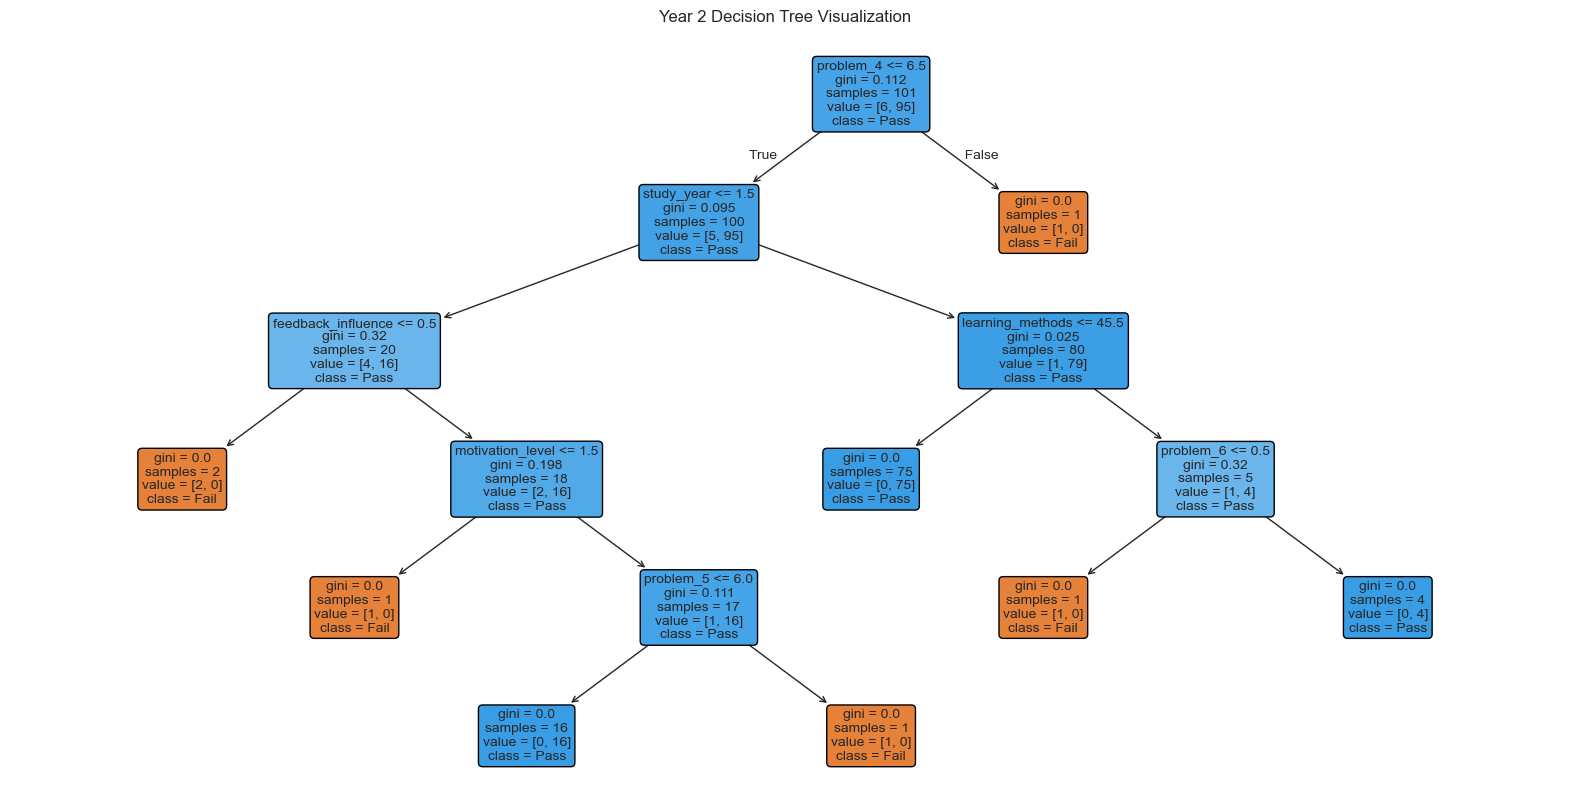

In [77]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Train a Decision Tree on the full Year 2 data
dt_y2 = DecisionTreeClassifier(random_state=42)
dt_y2.fit(X_year2, y_year2)

# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(
    dt_y2,
    feature_names=X_year2.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Year 2 Decision Tree Visualization")
plt.show()


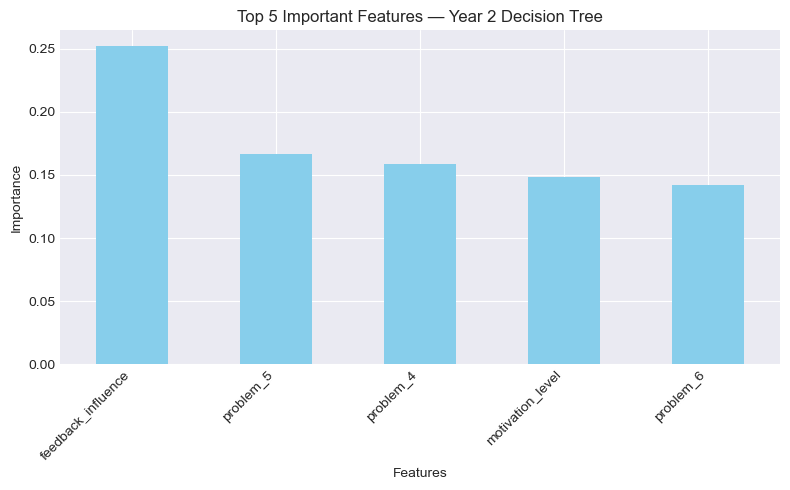

In [78]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Train a Decision Tree on full Year 2 data
dt_y2 = DecisionTreeClassifier(random_state=42)
dt_y2.fit(X_year2, y_year2)

# Get feature importances
feature_importances = pd.Series(dt_y2.feature_importances_, index=X_year2.columns)

# Sort and take top 5 features
top_features = feature_importances.sort_values(ascending=False).head(5)

# Plot
plt.figure(figsize=(8,5))
top_features.plot(kind='bar', color='skyblue')
plt.title("Top 5 Important Features — Year 2 Decision Tree")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
